In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Data Model - Pizza Sales.csv")

In [3]:
df


,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01/01/2015,11:38:36 AM,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01/01/2015,11:57:40 AM,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01/01/2015,11:57:40 AM,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01/01/2015,11:57:40 AM,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01/01/2015,11:57:40 AM,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,12/31/2015,09:23:10 PM,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,12/31/2015,09:23:10 PM,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,12/31/2015,09:23:10 PM,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,12/31/2015,10:09:54 PM,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [7]:
df.head()

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36 AM,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40 AM,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40 AM,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40 AM,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40 AM,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [10]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [11]:
print("Total Revenue:", df['total_price'].sum())


Total Revenue: 817860.05


In [12]:
print("Total Orders:", df['order_id'].nunique())

Total Orders: 21350


In [13]:
avg_order_value = df['total_price'].sum() / df['order_id'].nunique()
print("Average Order Value:", round(avg_order_value, 2))

Average Order Value: 38.31


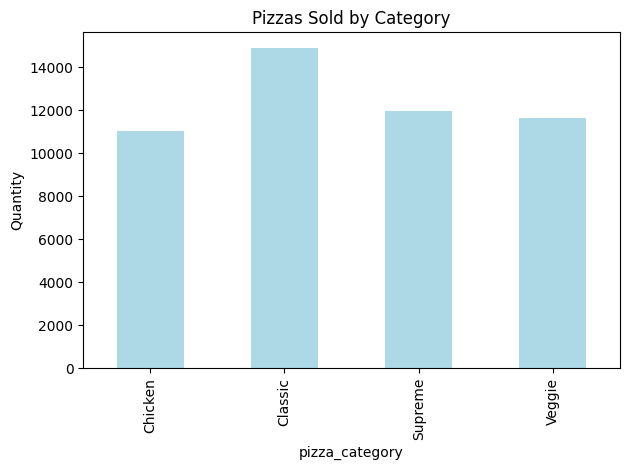

In [14]:
category_sales = df.groupby('pizza_category')['quantity'].sum()
category_sales.plot(kind='bar', title='Pizzas Sold by Category', color='lightblue')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

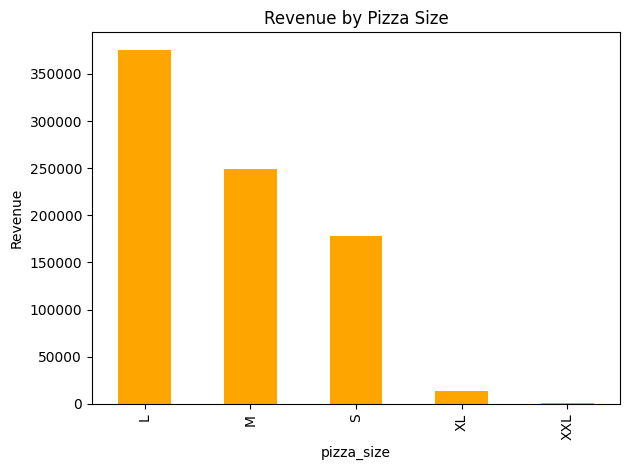

In [15]:
# 5. Revenue by Pizza Size
size_revenue = df.groupby('pizza_size')['total_price'].sum()
size_revenue.plot(kind='bar', title='Revenue by Pizza Size', color='orange')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

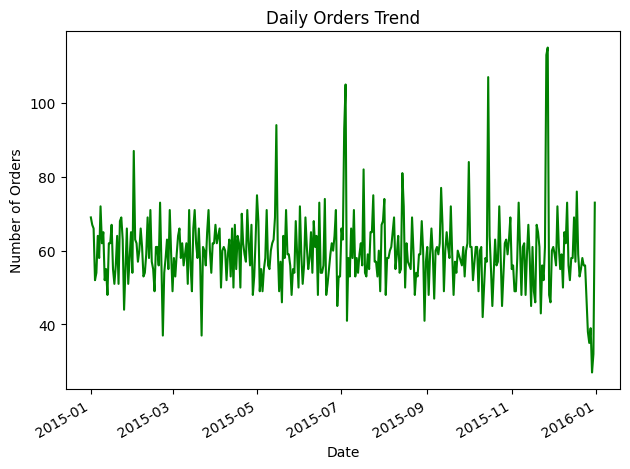

In [16]:
# 6. Orders Over Time (Daily Count)
daily_orders = df.groupby('order_date')['order_id'].nunique()
daily_orders.plot(kind='line', title='Daily Orders Trend', color='green')
plt.ylabel('Number of Orders')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

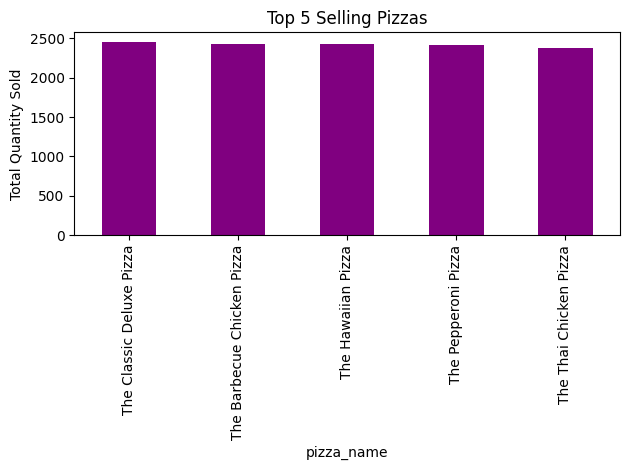

In [17]:
# 7. Top 5 Selling Pizzas by Quantity
top_pizzas = df.groupby('pizza_name')['quantity'].sum().nlargest(5)
top_pizzas.plot(kind='bar', title='Top 5 Selling Pizzas', color='purple')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

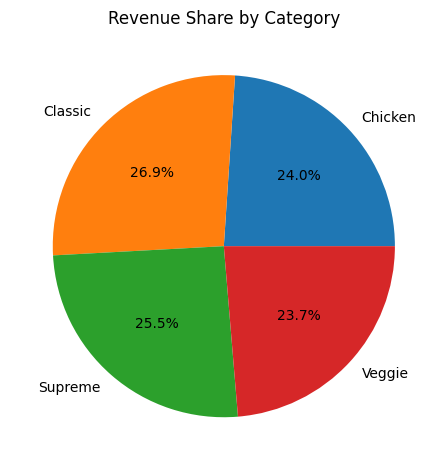

In [18]:
# 8. Pie Chart: Revenue Share by Category
category_revenue = df.groupby('pizza_category')['total_price'].sum()
category_revenue.plot(kind='pie', autopct='%1.1f%%', title='Revenue Share by Category', ylabel='')
plt.tight_layout()
plt.show()